### Data Visualization Task for Lotus

I will use Matplotlib, Seaborn, Plotly and maybe one more vis library for this task

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from warnings import filterwarnings
filterwarnings('ignore')

and for my dataset I found a nice automobile sales data

In [4]:
df = pd.read_csv('/Users/cenkerarin/lotus/Auto Sales data.csv')

In [6]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  PHONE                 2747 non-null   object 
 13  ADDRESSLINE1          2747 non-null   object 
 14  CITY                  2747 non-null   object 
 15  POSTALCODE           

lets split our data to numerical and categorical

In [9]:
df_num = df.select_dtypes(include=['float64', 'int64']).drop(columns=['ORDERNUMBER'])
print(df_num.columns, len(list(df_num.columns.values)))

Index(['QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES',
       'DAYS_SINCE_LASTORDER', 'MSRP'],
      dtype='object') 6


In [10]:
df_cat = df.select_dtypes(include = ['object']).drop(columns=['PHONE','ADDRESSLINE1', 'CONTACTLASTNAME','CONTACTFIRSTNAME'])
print(df_cat.columns, len(list(df_cat.columns.values)))

Index(['ORDERDATE', 'STATUS', 'PRODUCTLINE', 'PRODUCTCODE', 'CUSTOMERNAME',
       'CITY', 'POSTALCODE', 'COUNTRY', 'DEALSIZE'],
      dtype='object') 9


Text(0, 0.5, 'Count')

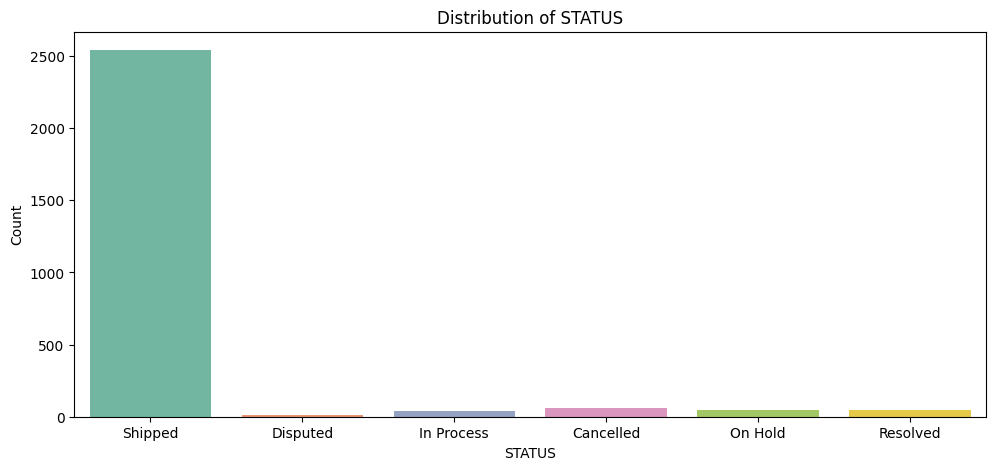

In [ ]:
plt.figure(figsize=(40, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='STATUS', palette='Set2')
plt.title('Distribution of STATUS')
plt.xlabel('STATUS')
plt.ylabel('Count')


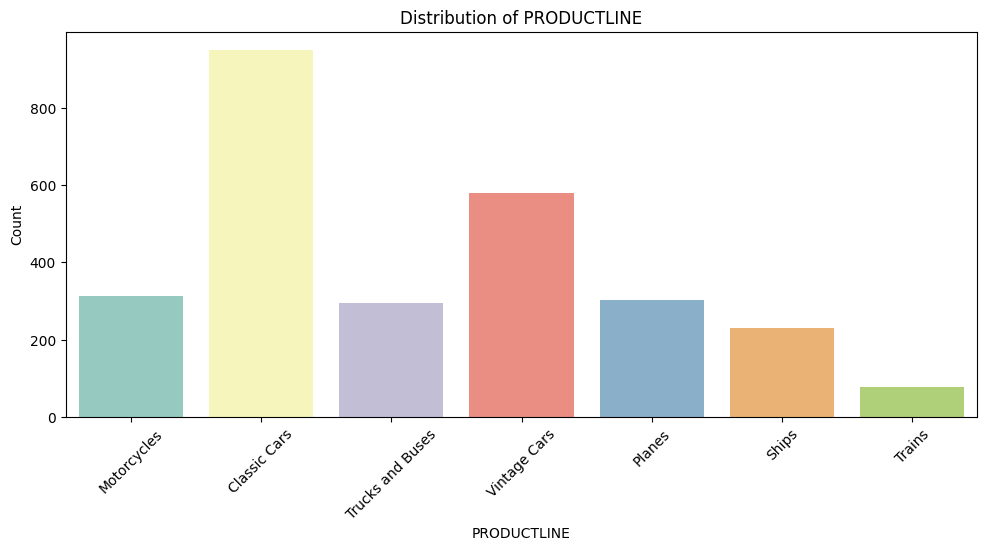

In [23]:
plt.figure(figsize=(40, 5))

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='PRODUCTLINE', palette='Set3')
plt.title('Distribution of PRODUCTLINE')
plt.xlabel('PRODUCTLINE')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

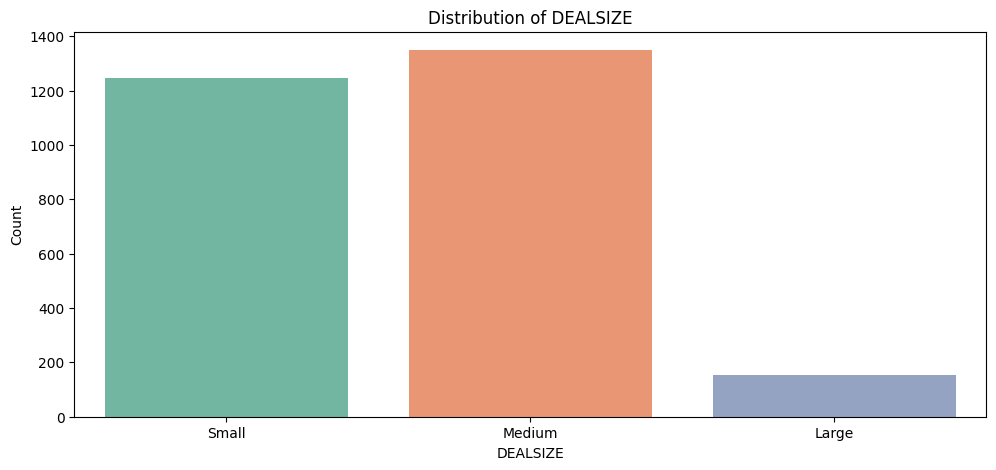

In [29]:
plt.figure(figsize=(40, 5))

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='DEALSIZE', palette='Set2')
plt.title('Distribution of DEALSIZE')
plt.xlabel('DEALSIZE')
plt.ylabel('Count')

plt.show()

Right now we visualized our data using **Bar Charts**

A bar chart is one of the most common visualization types used to represent categorical data.
Each category is shown with a bar, and the bar’s height or length is proportional to its value. Bars can be displayed vertically or horizontally

---

The main advantage of bar charts is their simplicity and readability. They make it easy to compare categories quickly and highlight the largest or smallest groups. Bar charts also support grouped or stacked variations, allowing comparisons between subcategories.

However bar charts can become cluttered if there are too many categories. They are not suitable for showing trends over time, where line charts are more effective. Additionally, they only show overall category values, without information about the data distribution (unlike box or violin plots).

Bar charts are best used when the goal is to compare discrete categories, show frequency counts, or highlight differences in quantities. Typical use cases include comparing sales by product, population by city, or survey results by group.

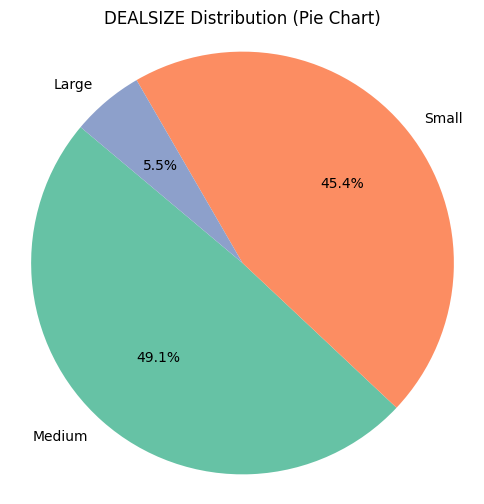

In [ ]:
dealsize_counts = df['DEALSIZE'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(dealsize_counts, labels=dealsize_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('DEALSIZE Distribution (Pie Chart)')
plt.axis('equal') 
plt.show()

this is a **Pie Chart**

A pie chart represents data as slices of a circle, where each slice corresponds to a category and its angle is proportional to the category’s value relative to the total. It is mainly used to show the composition or percentage breakdown of a whole.

The advantage of pie charts is their intuitive and visually appealing design. They make it easy to see which categories dominate and to highlight proportions at a glance. They work best with a small number of categories and when the focus is on relative contribution rather than exact values

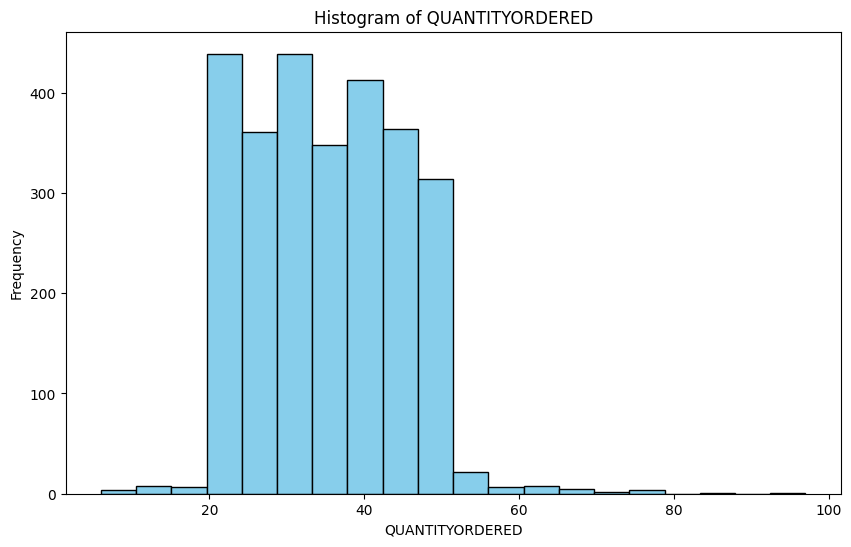

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['QUANTITYORDERED'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of QUANTITYORDERED')
plt.xlabel('QUANTITYORDERED')
plt.ylabel('Frequency')
plt.show()


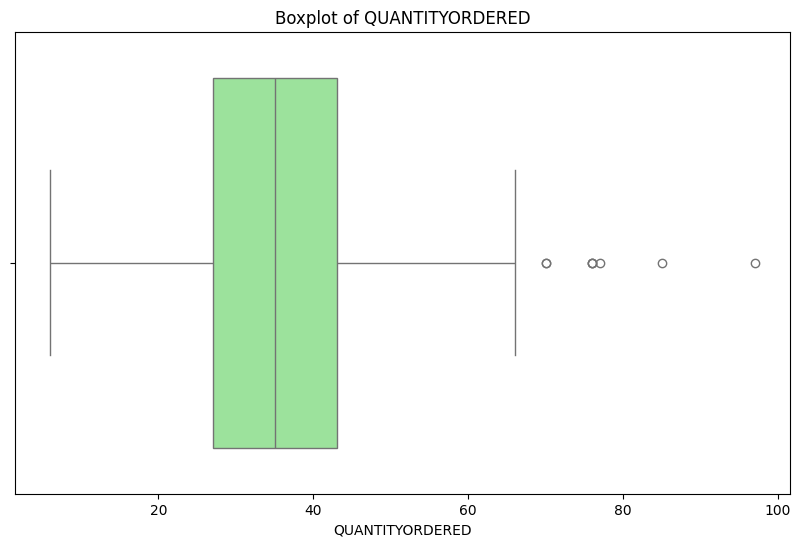

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['QUANTITYORDERED'], color='lightgreen')
plt.title('Boxplot of QUANTITYORDERED')
plt.xlabel('QUANTITYORDERED')
plt.show()

this is a **Box Plot**

A box plot is a statistical graph used to display the distribution of a dataset. It summarizes data through five key numbers: minimum, first quartile, median, third quartile, and maximum, outliers are often shown as individual points

The main advantage of box plots is that they provide a clear overview of data distribution, spread, and central tendency. They make it easy to identify medians, variability, and outliers in a compact format

However, box plots do not show the exact distribution shape, such as whether the data is multimodal. They are less intuitive for audiences unfamiliar with statistics compared to bar or pie charts

Box plots are best used when comparing distributions across multiple groups, spotting outliers, or understanding variability

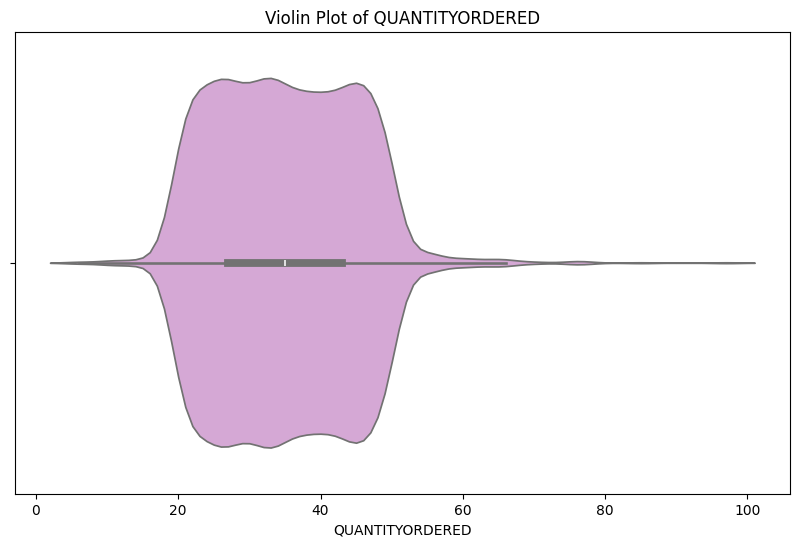

In [36]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['QUANTITYORDERED'], color='plum')
plt.title('Violin Plot of QUANTITYORDERED')
plt.xlabel('QUANTITYORDERED')
plt.show()

This is a **Violin Plot**.

A violin plot is a method of plotting numeric data that visualizes the distribution, probability density, and spread of a dataset. It combines features of a box plot and a kernel density plot, displaying the median, interquartile range, and the full distribution shape

The main advantage of violin plots is that they provide more information about the shape of the distribution than box plots, including multimodality and skewness. They are especially useful for comparing distributions between several groups or categories

However, violin plots can be less intuitive for audiences unfamiliar with density plots, and the appearance can be influenced by the choice of bandwidth in the kernel density estimation

Violin plots are best used when you want to compare the distribution and density of data across multiple groups, and when understanding the underlying distribution shape is important

---

The area where the violin plot is widest vertically represents where the data is most dense (high probability density).

if both sides of the violin are similar, the distribution is symmetric; if not, it is skewed.

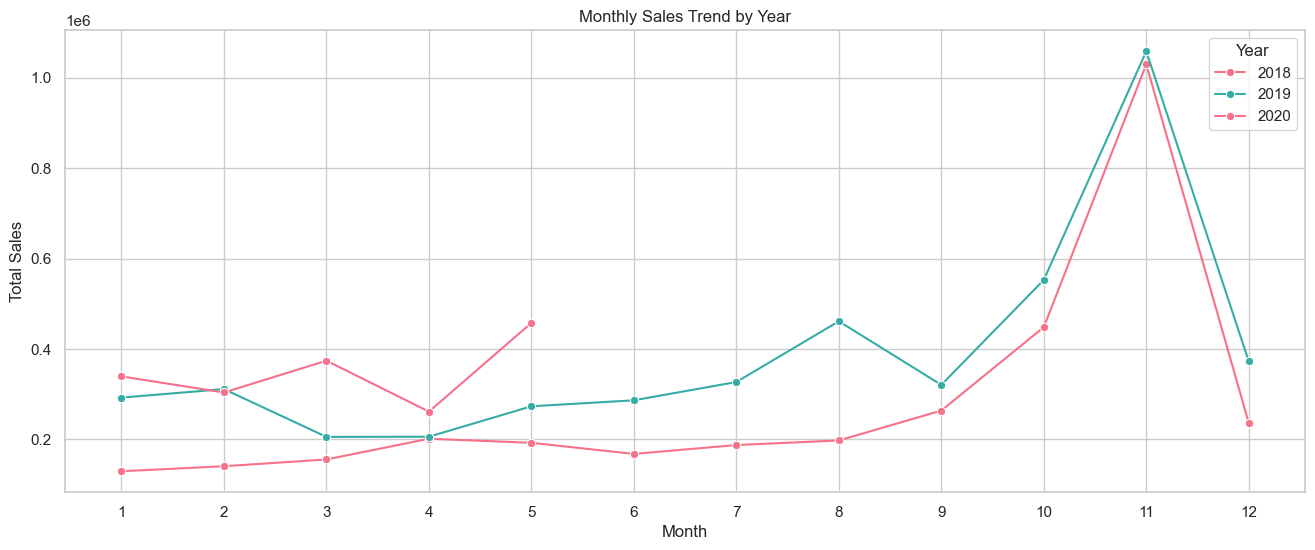

In [ ]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], dayfirst=True, errors='coerce')
df['Year'] = df['ORDERDATE'].dt.year
df['Month'] = df['ORDERDATE'].dt.month

sales_trend = df.groupby(['Year', 'Month'])['SALES'].sum().reset_index()

sns.set(style="whitegrid", rc={"figure.figsize": (16, 6)})
sns.lineplot(data=sales_trend, x="Month", y="SALES", hue="Year", marker="o", palette="husl")
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.legend(title="Year", loc='best')
plt.xticks(range(1, 13))
plt.show()

this is a **Line Chart** we used this one to showcase trends

A line chart is used to display data points connected by straight lines, usually over a continuous variable such as time. It is one of the most common tools for showing trends, patterns, and changes.

The main advantage of line charts is their ability to clearly show trends and relationships over time. They make it easy to detect increases, decreases, and cycles in the data. Multiple lines can be plotted together for comparison across groups.

However, line charts are not suitable for categorical data. Too many lines can clutter the chart, making it difficult to interpret. They also do not provide detailed information about data distribution.

Line charts are best used for time series analysis, tracking metrics, and identifying long-term trends.